<a href="https://colab.research.google.com/github/Hindabuzarour/Hindabuzarour/blob/main/Copy_of_Project_1_Part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Functions

In [5]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',figsize = (6,4), order = None):
 temp_df = df.copy()
 null_count = temp_df[x].isna().sum()
 null_perc = null_count/len(temp_df)* 100
 if fillna == True:
   temp_df[x].fillna(placeholder, inplace = True)
 fig, ax = plt.subplots(figsize=figsize)
 sns.countplot(data = temp_df, x = x, order = order)
 ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
 ax.set_title(f"Column: {x}", fontweight='bold')
 fig.tight_layout()
 plt.show()
 print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
 nunique = temp_df[x].nunique()
 print(f"- Unique Values: {nunique}")
 val_counts = temp_df[x].value_counts(dropna=False)
 most_common_val = val_counts.index[0]
 freq = val_counts.values[0]
 perc_most_common = freq / len(temp_df) * 100
 print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
 if perc_most_common > 98:
  print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
 else:
  print("- Not constant or quasi-constant.")
 return fig, ax

def explore_numeric(df, x, figsize=(6,5) ):
 gridspec = {'height_ratios':[0.7,0.3]}
 fig, axes = plt.subplots(nrows=2, figsize=figsize,sharex=True, gridspec_kw=gridspec)
 sns.histplot(data=df, x=x, ax=axes[0])
 sns.boxplot(data=df, x=x, ax=axes[1])
 axes[0].set_title(f"Column: {x}", fontweight='bold')
 fig.tight_layout()
 plt.show()
 print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
 nunique = df[x].nunique()
 print(f"- Unique Values: {nunique}")
 most_common_val_count = df[x].value_counts(dropna=False).head(1)
 most_common_val = most_common_val_count.index[0]
 freq = most_common_val_count.values[0]
 perc_most_common = freq / len(df) * 100
 print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
 if perc_most_common > 98:
  print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
 else:
  print("- Not constant or quasi-constant.")
 return fig, axes

In [33]:
def plot_categorical_vs_target(df, x, y='rating',figsize=(6,4),fillna = True, placeholder = 'MISSING', order = None):
  temp_df = df.copy()
  if fillna == True:
    temp_df[x].fillna(placeholder, inplace = True)
  else:
    temp_df = temp_df.dropna(subset=[x])
  fig, ax = plt.subplots(figsize=figsize)
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,linewidth=1, edgecolor='black', errorbar=None)
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax, order=order, hue_order=order, legend=False,edgecolor='white', linewidth=0.5,size=3,zorder=0)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  ax.set_title(f"Column: {x}", fontweight='bold')
  fig.tight_layout()
  return fig, ax
def plot_numeric_vs_target(df, x, y='rating',figsize=(6,4),):
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','s':50,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')
  plt.show()
  return fig, ax



# Loading Data

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
fpath= '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df_sales = pd.read_csv(fpath)
# view first 5 rows
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


- Outlet_Type

In [22]:
feature='Outlet_Type'
df_sales[feature].dtype

dtype('O')

<ipython-input-5-274142f33e11>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[x].fillna(placeholder, inplace = True)
<ipython-input-5-274142f33e11>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


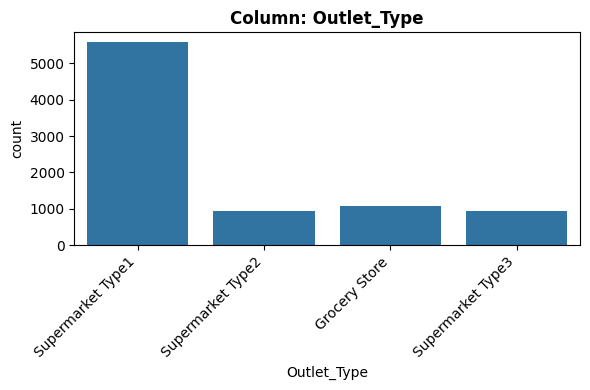

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [25]:
explore_categorical(df_sales,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0.0%)


3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 4 unique categories.
  - Not high cardinality (not >10)

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

- Item_Type

<ipython-input-5-274142f33e11>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[x].fillna(placeholder, inplace = True)
<ipython-input-5-274142f33e11>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


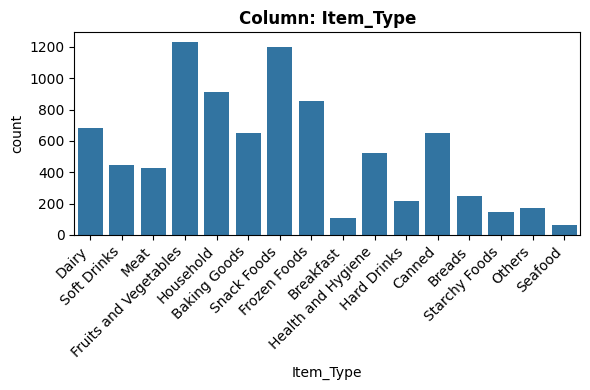

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [26]:
feature='Item_Type'
df_sales[feature].dtype
explore_categorical(df_sales,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 (0.0%)


3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  -  16 unique categories.
  -  high cardinality

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

- Item_MRP

In [30]:
feature='Item_MRP'
df_sales[feature].dtype

dtype('float64')

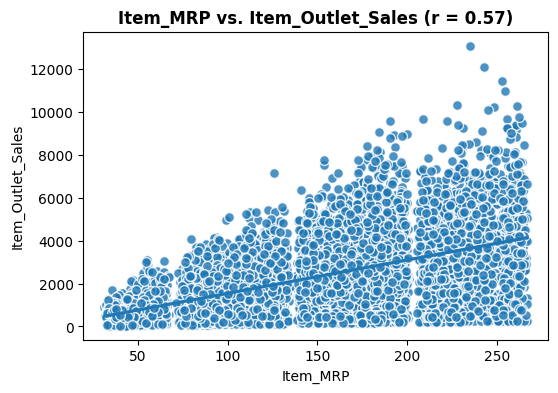

In [34]:
plot_numeric_vs_target(df_sales,feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes,
  - Does this feature appear to be a predictor of the target?
    - Yes